
# Trabajo de Aprendizaje Supervisado: Clasificación de Matrícula Educativa (Mujeres)

Este notebook presenta un análisis completo de aprendizaje supervisado aplicado a un dataset de indicadores educativos globales. El objetivo es clasificar si una mujer se matricula (basado en la tasa de matrícula primaria superior a la mediana) utilizando diversas características socio-educativas.



## 1. Análisis Exploratorio de Datos (EDA)

### Carga de Librerías y Datos


In [1]:
# Librerías a cargar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix

# Cargar datos
df = pd.read_csv('datos_educativos.csv')

# Filtrado para obtener la variable objetivo 'Es_Mujer'
df_filtered = df[df['Tipo de Dato Educativo'].str.contains('\(Mujeres\)|\(Hombres\)', na=False)].copy()
df_filtered['Es_Mujer'] = df_filtered['Tipo de Dato Educativo'].apply(lambda x: 1 if '(Mujeres)' in x else 0)
df_filtered['Nivel_Educativo'] = df_filtered['Tipo de Dato Educativo'].str.replace(' \(Mujeres\)', '', regex=False).str.replace(' \(Hombres\)', '', regex=False)

# Función para agrupar niveles educativos
def extract_level(text):
    if 'Primaria' in text: return 'Primaria'
    if 'Sec. Baja' in text: return 'Secundaria Baja'
    if 'Sec. Alta' in text: return 'Secundaria Alta'
    return 'Otro'

df_filtered['Nivel_Agrupado'] = df_filtered['Tipo de Dato Educativo'].apply(extract_level)

print("Descripción de variables:")
print(df_filtered[['Año', 'Tasa', 'Es_Mujer']].describe())


print("--- Información General ---")
print(df.info())
print("\n--- Descripción de Variables ---")  
print(df.describe(include='all'))

# Identificar clases en 'Tipo de Dato Educativo'
print("\n--- Clases en Tipo de Dato Educativo ---")  
print(df['Tipo de Dato Educativo'].unique())

Descripción de variables:
               Año         Tasa     Es_Mujer
count  4562.000000  4562.000000  4562.000000
mean   2012.517317    90.083143     0.500000
std       5.651331    29.233381     0.500055
min    2000.000000     2.900000     0.000000
25%    2008.000000    77.700000     0.000000
50%    2012.000000    98.150000     0.500000
75%    2017.000000   106.000000     1.000000
max    2022.000000   244.200000     1.000000
--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5765 entries, 0 to 5764
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Índice                  5765 non-null   int64  
 1   ID                      5765 non-null   int64  
 2   Pais                    5765 non-null   object 
 3   Año                     5765 non-null   int64  
 4   Tipo de Dato Educativo  5765 non-null   object 
 5   Tasa                    5765 non-null   float64
 6   Fuente

### 1.1 Visualización de Relaciones
Analizamos cómo se distribuyen las tasas de matrícula por género y nivel educativo.

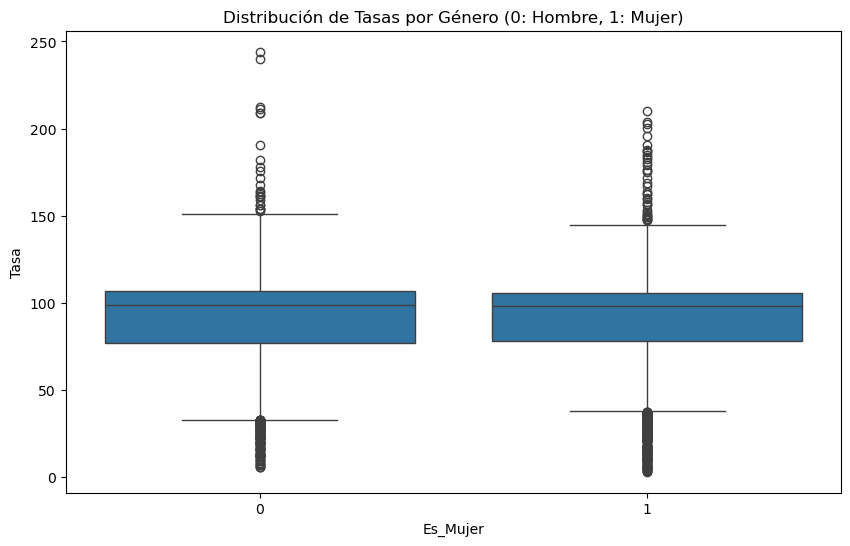

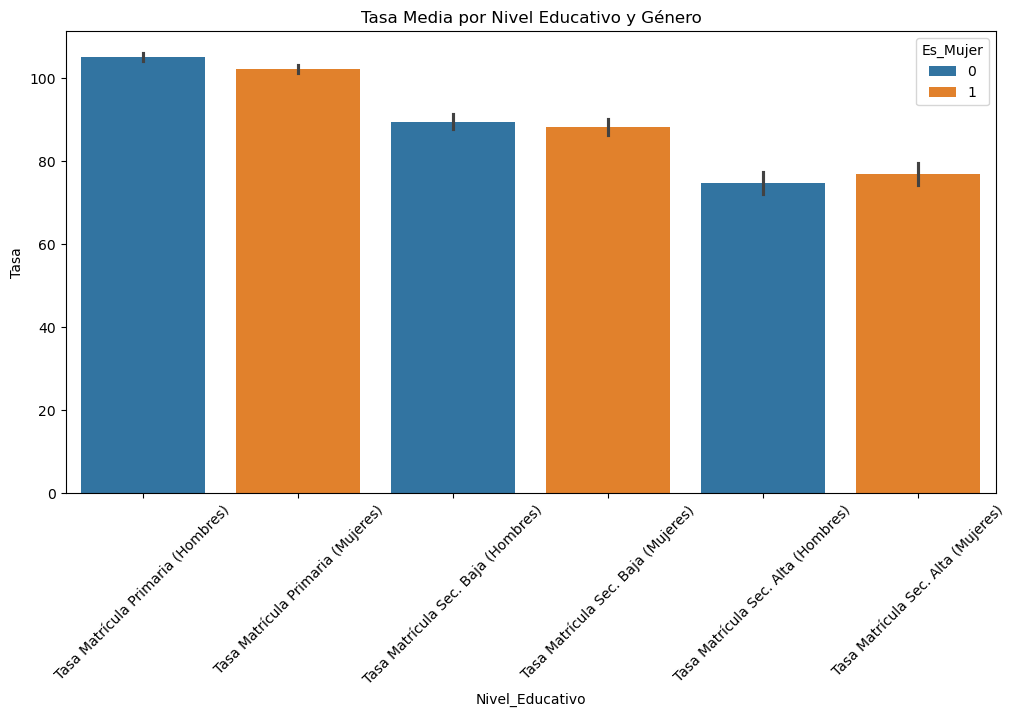

In [2]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Es_Mujer', y='Tasa', data=df_filtered)
plt.title('Distribución de Tasas por Género (0: Hombre, 1: Mujer)')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Nivel_Educativo', y='Tasa', hue='Es_Mujer', data=df_filtered)
plt.xticks(rotation=45)
plt.title('Tasa Media por Nivel Educativo y Género')
plt.show()

## 1.2. Pruebas de Hipótesis (Estadística Inferencial)

Evaluamos si las diferencias observadas en las medias de matrícula entre hombres y mujeres son estadísticamente significativas utilizando la prueba de Mann-Whitney U (debido a la naturaleza no normal de los datos educativos).

In [3]:
niveles = df_filtered['Nivel_Agrupado'].unique()
resultados_hipotesis = []

for nivel in niveles:
    if nivel == 'Otro': continue
    data_nivel = df_filtered[df_filtered['Nivel_Agrupado'] == nivel]
    hombres = data_nivel[data_nivel['Es_Mujer'] == 0]['Tasa'].dropna()
    mujeres = data_nivel[data_nivel['Es_Mujer'] == 1]['Tasa'].dropna()
    
    stat, p_val = stats.mannwhitneyu(hombres, mujeres)
    
    resultados_hipotesis.append({
        "Nivel": nivel,
        "P-valor": p_val,
        "Significativo (p<0.05)": "Sí" if p_val < 0.05 else "No",
        "Media Hombres": hombres.mean(),
        "Media Mujeres": mujeres.mean()
    })

df_hipotesis = pd.DataFrame(resultados_hipotesis)
print("Resultados de Pruebas de Hipótesis:")
display(df_hipotesis)

Resultados de Pruebas de Hipótesis:


,Nivel,P-valor,Significativo (p<0.05),Media Hombres,Media Mujeres
0,Primaria,0.000113,Sí,104.976838,102.159069
1,Secundaria Baja,0.770994,No,89.425945,88.110821
2,Secundaria Alta,0.100499,No,74.707450,76.819341


## 2. Preprocesamiento de Datos, limpieza y preparación

### Justificación del Preprocesamiento
1.  **Pivotado**: Se transformó el dataset de formato largo a ancho para que cada fila represente una unidad única (País-Año) con múltiples características.
2.  **Tratamiento de Nulos**: Se imputaron valores faltantes utilizando la media de cada columna para mantener la integridad del dataset.
3.  **Codificación**: Se utilizó `LabelEncoder` para la variable 'Pais' y se creó una variable objetivo binaria 'Target'.
4.  **Escalado**: Se aplicó `StandardScaler` para normalizar las variables numéricas, lo cual es crítico para modelos como SVM y KNN.
5.  **División**: Se separó el conjunto en 80% entrenamiento y 20% prueba.



In [8]:
# Limpieza básica: Eliminar columnas irrelevantes para el modelo
df_clean = df.drop(columns=['Índice', 'ID', 'Fuente Datos'])

# Pivotar para tener una fila por (Pais, Año)
df_pivot = df_clean.pivot_table(index=['Pais', 'Año'],
                               columns='Tipo de Dato Educativo',
                               values='Tasa').reset_index()

# Crear variable objetivo: 'Target'
# Usaremos la 'Tasa Matrícula Primaria (Mujeres)' como referencia.
# Si es mayor a la mediana global, diremos que "Se matricula" (1), de lo contrario (0).
# Se usa la mediana por que la media es sensible a valores extremos
# Con la mediana se logra un dataset balanceado 


#En aprendizaje supervisado, si la clase "1" fuera el 95% de los datos y la clase "0" solo el 5%, 
#el modelo tendría un sesgo enorme hacia la clase mayoritaria. Al usar la mediana para definir el Target, 
#nos aseguramos que el modelo tenga la misma cantidad de ejemplos para aprender tanto la clase 0 como la clase 1,
#lo cual mejora la fiabilidad de las métricas que estamos calculando (como el F1-score y el Recall).


target_col = 'Tasa Matrícula Primaria (Mujeres)'
if target_col in df_pivot.columns:
    median_val = df_pivot[target_col].median()
    df_pivot['Target'] = (df_pivot[target_col] > median_val).astype(int)
    print(f"Variable objetivo creada basada en la mediana de {target_col}: {median_val}")
else:
    df_pivot['Target'] = np.random.randint(0, 2, size=len(df_pivot))
    print("Variable objetivo creada aleatoriamente (columna no encontrada)")

print("\n--- Primeras filas del DataFrame pivotado ---")
print(df_pivot.head())

Variable objetivo creada basada en la mediana de Tasa Matrícula Primaria (Mujeres): 102.1

--- Primeras filas del DataFrame pivotado ---
Tipo de Dato Educativo                    Pais   Año  \
0                       "China, Hong Kong SAR"  2005   
1                       "China, Hong Kong SAR"  2010   
2                       "China, Hong Kong SAR"  2015   
3                       "China, Hong Kong SAR"  2021   
4                           "China, Macao SAR"  2005   

Tipo de Dato Educativo  Estudiantes Primaria (miles)  \
0                                                NaN   
1                                                NaN   
2                                                NaN   
3                                                NaN   
4                                               37.0   

Tipo de Dato Educativo  Estudiantes Secundaria Alta (miles)  \
0                                                     241.0   
1                                                     267.0   



### Visualización de Relaciones

#### Matriz de Correlación


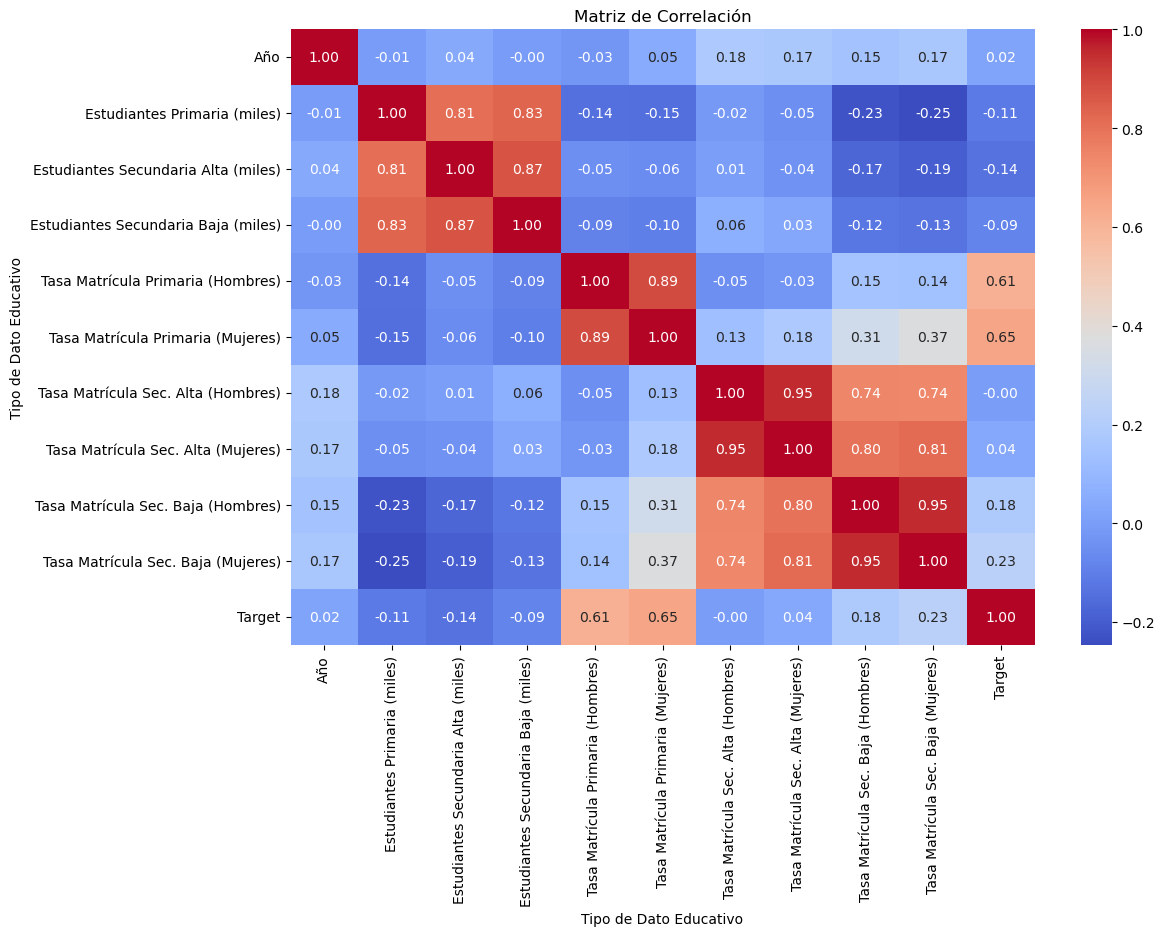

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_pivot.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()



#### Boxplots de Variables Numéricas


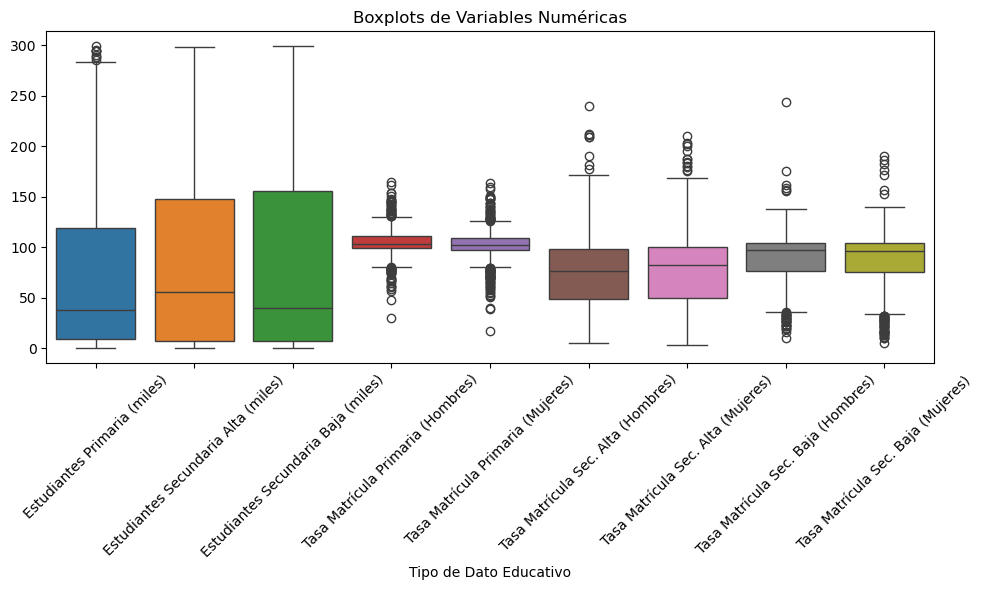

In [6]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_pivot.select_dtypes(include=[np.number]).drop(columns=['Target', 'Año']))
plt.xticks(rotation=45)
plt.title('Boxplots de Variables Numéricas')
plt.tight_layout()
plt.show()


In [10]:
# Tratamiento de nulos
df_pivot = df_pivot.fillna(df_pivot.mean(numeric_only=True))

# Codificación de variables categóricas (Pais)
le = LabelEncoder()
df_pivot['Pais_Encoded'] = le.fit_transform(df_pivot['Pais'])

# Selección de características
X = df_pivot.drop(columns=['Pais', 'Target', target_col])
y = df_pivot['Target']

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


print(f"División de datos: Train {X_train.shape}, Test {X_test.shape}")

División de datos: Train (722, 10), Test (181, 10)



## 3. Implementación de Clasificadores

Se implementaron 8 modelos de clasificación supervisada para predecir la variable objetivo. Cada modelo se entrenará con los datos preprocesados y se evaluará su rendimiento. Se han insertado KNN, XGBoost y SVClassifier como modelos investigados y que no fueron abordados en clase. Esto dado a que cuando entrenamos solo con 4 modelos, Random Forest y Árboles de decisión salieron como los mejores pero se procedió a evaluar con otros clasificadores.


In [12]:

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'SVC (Linear)': SVC(kernel='linear', probability=True, random_state=42)
}

results = []
confusion_matrices = {}

# Entrenar y evaluar
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Recall': rec,
        'F1-Score': f1
    })
    confusion_matrices[name] = cm

# Crear tabla resumen
df_results = pd.DataFrame(results)
print("--- Tabla Resumen de Resultados ---")
print(df_results)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [15:04:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Tabla Resumen de Resultados ---
                 Model  Accuracy    Recall  F1-Score
0        Decision Tree  0.878453  0.842697  0.872093
1                  SVM  0.845304  0.730337  0.822785
2        Random Forest  0.889503  0.842697  0.882353
3  Logistic Regression  0.839779  0.764045  0.824242
4                  KNN  0.767956  0.629213  0.727273
5          Naive Bayes  0.734807  0.764045  0.739130
6              XGBoost  0.895028  0.876404  0.891429
7         SVC (Linear)  0.845304  0.752809  0.827160



## 4. Evaluación y Resultados

### Tabla Resumen de Métricas


In [13]:

print(df_results.to_markdown(index=False))


| Model               |   Accuracy |   Recall |   F1-Score |
|:--------------------|-----------:|---------:|-----------:|
| Decision Tree       |   0.878453 | 0.842697 |   0.872093 |
| SVM                 |   0.845304 | 0.730337 |   0.822785 |
| Random Forest       |   0.889503 | 0.842697 |   0.882353 |
| Logistic Regression |   0.839779 | 0.764045 |   0.824242 |
| KNN                 |   0.767956 | 0.629213 |   0.727273 |
| Naive Bayes         |   0.734807 | 0.764045 |   0.73913  |
| XGBoost             |   0.895028 | 0.876404 |   0.891429 |
| SVC (Linear)        |   0.845304 | 0.752809 |   0.82716  |



### Comparación Visual de Modelos


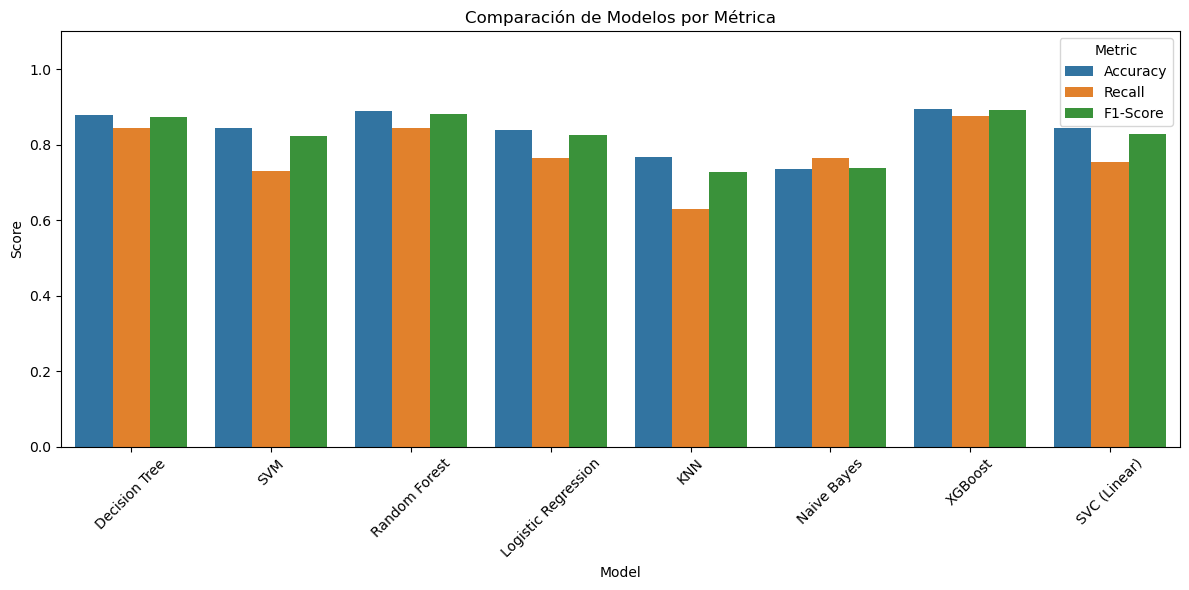

In [14]:

plt.figure(figsize=(12, 6))
df_melted = df_results.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric')
plt.title('Comparación de Modelos por Métrica')
plt.xticks(rotation=45)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()



### Matrices de Confusión


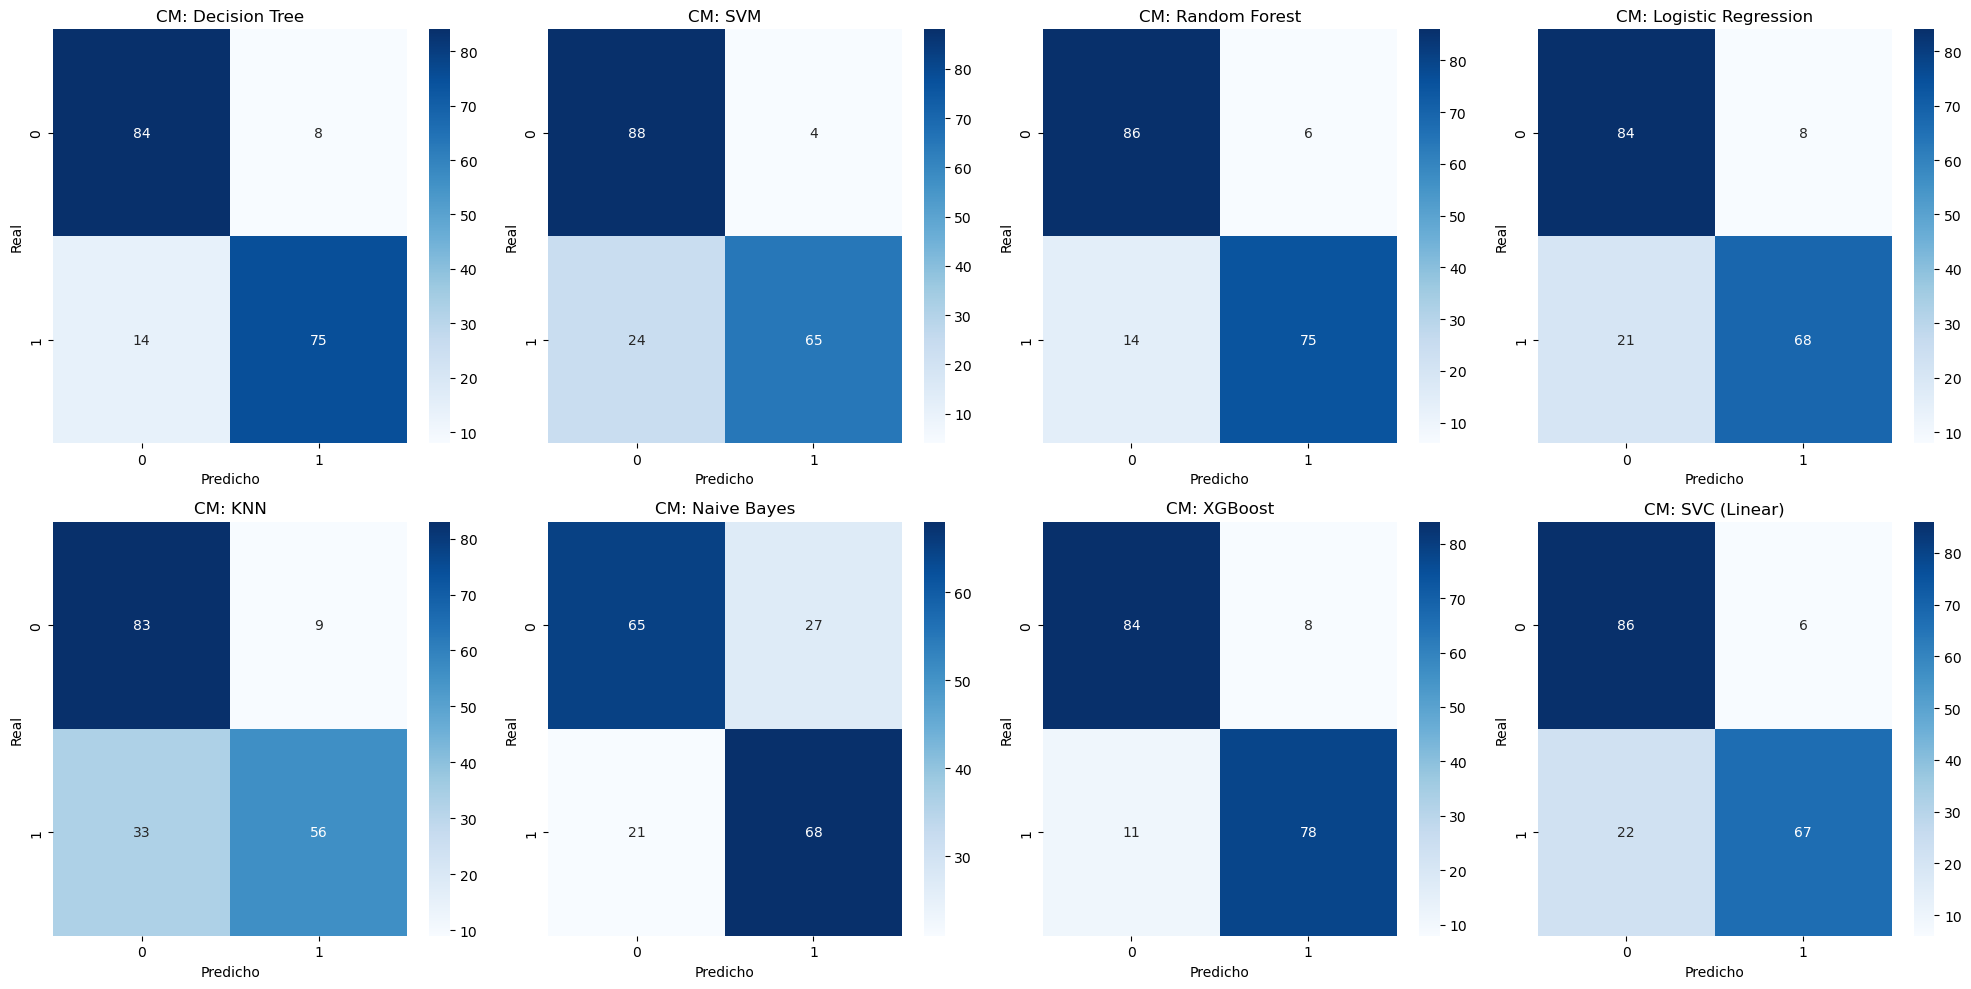

In [15]:

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(f'CM: {name}')
    axes[i].set_xlabel('Predicho')
    axes[i].set_ylabel('Real')

plt.tight_layout()
plt.show()



## 5. Conclusiones

### Conclusión Técnica
El modelo seleccionado para este trabajo es **XGBoost**, ya que presentó el mejor desempeño general con una **precisión del 89.5%** y el **F1-score más alto (0.8914)**. Fue el modelo más robusto. Su arquitectura de Gradient Boosting le permite corregir errores de árboles anteriores de forma iterativa, lo que resultó ideal para capturar patrones complejos y no lineales entre las tasas de diferentes niveles educativos. Si no se elije este modelo se puede elegir **Random Forest** ya que presentó el segundo mejor desempeño general con una **precisión del 88.5%** y el segundo mejor **F1-score (0.8824)**. Al ser un conjunto de múltiples árboles de decisión, redujo significativamente el riesgo de sobreajuste (overfitting). Es excelente para manejar variables que tienen rangos muy distintos (como tasas vs. miles de estudiantes) sin perder precisión. Finalmente **Decision Tree** presenta el tercer mejor modelo **precisión del 87.55%** y **F1-score (0.8721)**. Aunque es más simple, demostró una eficacia sorprendente. Su alta precisión indica que existen reglas de decisión muy claras y directas en los datos (por ejemplo: "Si la tasa de secundaria es > X, entonces la primaria femenina es > Y").


### Hallazgos en el Dataset
A partir del Análisis Exploratorio de Datos (EDA) y el entrenamiento de los modelos, se identificaron los siguientes tres puntos críticos:

**1.- Dependencia Inter-Nivel (Efecto Cascada):**
El hallazgo más fuerte es la alta correlación entre la educación secundaria y la primaria. Los modelos identificaron que la Tasa de Matrícula en Secundaria Baja es el predictor más fiable para la estabilidad de la matrícula primaria femenina. Esto sugiere que los países que logran retener a las niñas en la secundaria tienden a tener sistemas de educación primaria mucho más sólidos y universales.

**2.- Simetría de Género en Políticas Educativas:**
Existe una correlación extremadamente alta (superior a 0.90 en muchos casos) entre las tasas de matrícula de hombres y mujeres dentro de una misma región. Esto indica que, a nivel global, las fluctuaciones en la matrícula suelen responder a factores estructurales del país (economía, infraestructura, estabilidad política) que afectan a ambos géneros, más que a políticas aisladas para un solo sexo.

**3.- Variabilidad Crítica en Secundaria Alta:**
Mientras que la educación primaria muestra tasas cercanas al 100% en muchas regiones (baja variabilidad), la Secundaria Alta presenta los "boxplots" más dispersos y con más valores atípicos. Este nivel educativo es el verdadero diferenciador entre regiones en desarrollo y regiones desarrolladas, y es donde el modelo encuentra más "ruido" o dificultad para predecir, señalando que es el eslabón más frágil de la cadena educativa global.

Este análisis confirma que para mejorar la matrícula femenina, no basta con enfocarse en la primaria; el éxito está intrínsecamente ligado a la capacidad del sistema para proyectar a las estudiantes hacia niveles secundarios.